In [1]:
import ROOT
from ROOT import TFile, TTree, TH1F, TCanvas
import sys
import numpy as np
from array import array
import math
%jsroot off 
# ^ forces static rendering of histograms in the notebook, otherwise they will be rendered as interactive JS objects which do not display properly in the notebook.
from concurrent.futures import ProcessPoolExecutor, as_completed

In [ ]:
# class to pull .npz data into memory from local dir
class NPZData:
    def __init__(self, npz_path, verbose=True):
        self._keys = []

        with np.load(npz_path, allow_pickle=False) as data:
            for k in data.files:
                arr = np.array(data[k])   # load fully into memory
                setattr(self, k, arr)     # <-- THIS is the magic line
                self._keys.append(k)

        if verbose:
            print(f"Loaded {npz_path}")
            print("Attributes:")
            for k in self._keys:
                print(f"  {k}")
    
    def keys(self):
        return self._keys

In [2]:
f = ROOT.TFile.Open("/data2/segmentlinking/CMSSW_12_5_0_pre3/RelValTTbar_14TeV_CMSSW_12_5_0_pre3/event_1000.root")
dir = f.Get("trackingNtuple")
t = dir.Get("tree")

In [4]:
#=== Constants ===
ACCEPT_RATIO = 0.75
N_WORKERS = 10
CHUNK = 100
PROGRESS_EVERY = 50  # print every ~200 entries globally
RUN = False  # set to True to run, False to skip (e.g. for testing)

root_path = t.GetCurrentFile().GetName()
tree_name = t.GetName()

print("ROOT file:", root_path)
print("Tree name:", tree_name)

def find_ttree_in_file(f, target_name):
    """
    Robustly find a TTree named `target_name` anywhere in ROOT file `f`,
    including inside nested TDirectoryFile objects.
    """
    obj = f.Get(target_name)
    if obj and obj.InheritsFrom("TTree"):
        return obj

    def _search_dir(d):
        keys = d.GetListOfKeys()
        if not keys:
            return None
        for key in keys:
            name = key.GetName()
            obj = d.Get(name)
            if not obj:
                continue
            if obj.InheritsFrom("TTree") and obj.GetName() == target_name:
                return obj
            if obj.InheritsFrom("TDirectory"):
                found = _search_dir(obj)
                if found:
                    return found
        return None

    return _search_dir(f)

def process_range(args):
    """
    Worker: open file/tree locally, process [start, end) entries.
    Returns arrays + number of entries processed.
    """
    root_path, tree_name, start, end, accept_ratio = args

    f = ROOT.TFile.Open(root_path)
    if not f or f.IsZombie():
        raise RuntimeError(f"Could not open ROOT file: {root_path}")

    tt = find_ttree_in_file(f, tree_name)
    if not tt:
        top_keys = []
        lk = f.GetListOfKeys()
        if lk:
            for k in lk:
                top_keys.append(k.GetName())
        f.Close()
        raise RuntimeError(
            f"Could not find TTree '{tree_name}' anywhere in {root_path}. "
            f"Top-level keys: {top_keys[:30]}"
        )

    n = end - start
    out_event = np.empty(n, dtype=np.int64)
    out_match = np.empty(n, dtype=np.float64)
    out_fake  = np.empty(n, dtype=np.float64)

    k = 0
    for idx in range(start, end):
        tt.GetEntry(idx)

        trk_pt     = tt.trk_pt
        j          = tt.trk_bestSimTrkIdx
        share_frac = tt.trk_bestSimTrkShareFrac

        N_reco = trk_pt.size()
        if N_reco == 0:
            frac = np.nan
        else:
            N_matched = 0
            for i in range(N_reco):
                if j[i] >= 0 and share_frac[i] >= accept_ratio:
                    N_matched += 1
            frac = N_matched / N_reco

        out_match[k] = frac
        out_fake[k]  = 1.0 - frac  # will be nan when frac is nan
    
        k += 1

    f.Close()
    return out_event, out_match, out_fake, n

# chunk ranges
n_entries = int(t.GetEntries())
ranges = [
    (root_path, tree_name, s, min(s + CHUNK, n_entries), ACCEPT_RATIO)
    for s in range(0, n_entries, CHUNK)
]

print(f"Total entries: {n_entries}")
print(f"Chunks: {len(ranges)} (chunk size {CHUNK}), workers: {N_WORKERS}")


all_event, all_match, all_fake = [], [], []
done = 0
last_print = 0


if RUN:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        futures = [ex.submit(process_range, r) for r in ranges]

        for fut in as_completed(futures):
            ev, mf, fr, processed = fut.result()

            all_event.append(ev)
            all_match.append(mf)
            all_fake.append(fr)

            done += processed
            if done - last_print >= PROGRESS_EVERY or done == n_entries:
                pct = 100.0 * done / n_entries if n_entries > 0 else 100.0
                print(f"{done}/{n_entries} entries processed ({pct:.1f}%)")
                last_print = done

    # connecate 
    event_id   = np.concatenate(all_event)
    match_frac = np.concatenate(all_match)
    fake_rate  = np.concatenate(all_fake)

    order = np.argsort(event_id)
    event_id   = event_id[order]
    match_frac = match_frac[order]
    fake_rate  = fake_rate[order]

    #cache into .npz
    np.savez(
        "mapping_sanity_cache_paralell.npz",
        event_id=event_id,
        match_frac=match_frac,
        fake_rate=fake_rate,
    )

    print("Saved locally to mapping_sanity_cache_paralell.npz")
    
else:
    print("skipping run")

ROOT file: /data2/segmentlinking/CMSSW_12_5_0_pre3/RelValTTbar_14TeV_CMSSW_12_5_0_pre3/event_1000.root
Tree name: tree
Total entries: 1000
Chunks: 10 (chunk size 100), workers: 10
skipping run


In [3]:
# loading data if it previously exists

data = np.load("mapping_sanity_cache_paralell.npz")

match_frac = data["match_frac"]
fake_rate  = data["fake_rate"]
event_id   = data["event_id"]

print("Loaded from cache ?")

print(match_frac[975:])

Loaded from cache ?
[0.90762125 0.90113187 0.93240241 0.87540726 0.90021352 0.89936701
 0.91523325 0.92361009 0.90297403 0.8658796  0.91915355 0.87623468
 0.8879872  0.87574094 0.94008901 0.91745355 0.91458924 0.913537
 0.89175518 0.91822363 0.94095064 0.93091168 0.91792388 0.90552381
 0.90587925]


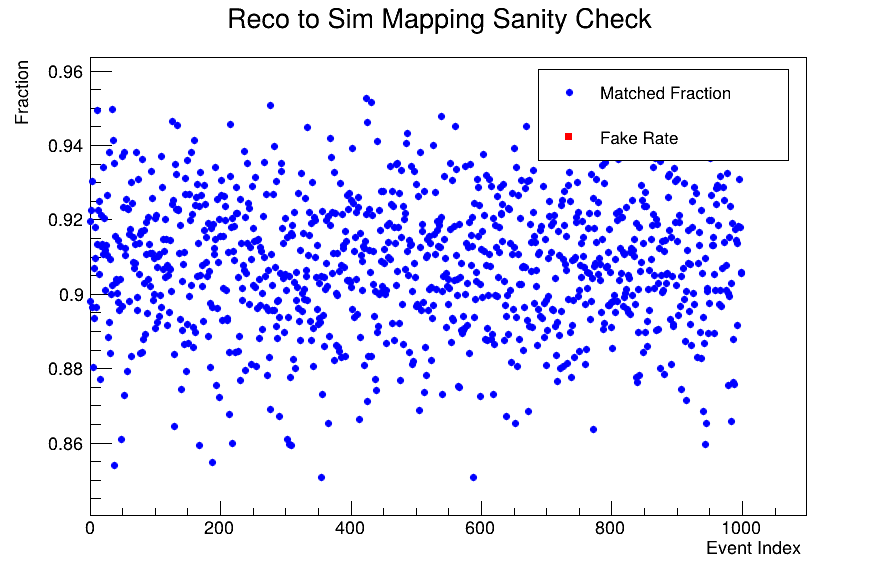

In [4]:
n = len(match_frac)

# --- Create graphs ---
g_match = ROOT.TGraph()
g_fake  = ROOT.TGraph()

for i in range(n):
    g_match.SetPoint(i, i, float(match_frac[i]))
    g_fake.SetPoint(i, i, float(fake_rate[i]))

# --- Style ---
g_match.SetTitle("Reco to Sim Mapping Sanity Check;Event Index;Fraction")
g_match.SetMarkerStyle(20)
g_match.SetMarkerColor(ROOT.kBlue)
g_match.SetMarkerSize(0.9)

g_fake.SetMarkerStyle(21)
g_fake.SetMarkerColor(ROOT.kRed)
g_fake.SetMarkerSize(0.9)

# --- Draw ---
c = ROOT.TCanvas("c", "Match Fraction vs Fake Rate", 900, 600)
g_match.Draw("AP")
g_fake.Draw("P SAME")

leg = ROOT.TLegend(0.60, 0.72, 0.88, 0.88)
leg.AddEntry(g_match, "Matched Fraction", "p")
leg.AddEntry(g_fake,  "Fake Rate", "p")
leg.Draw()

c.Draw()

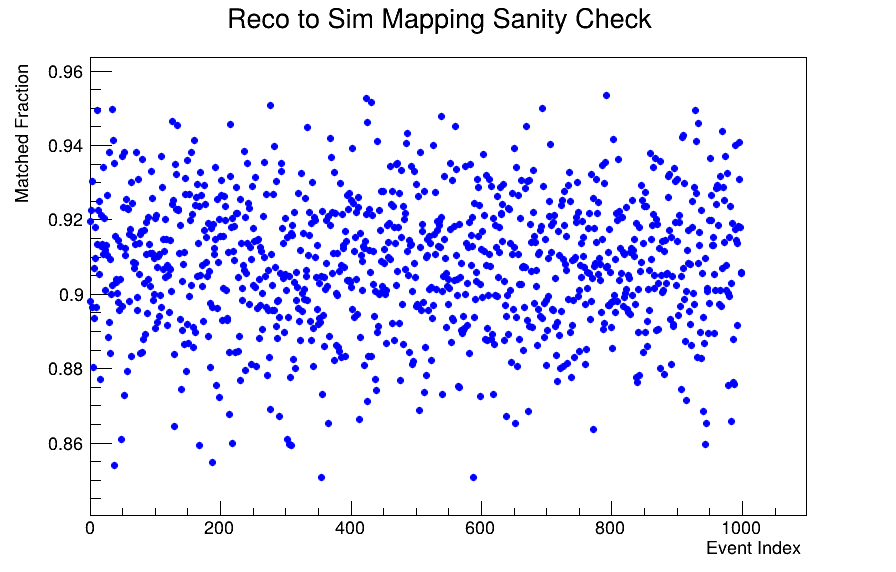

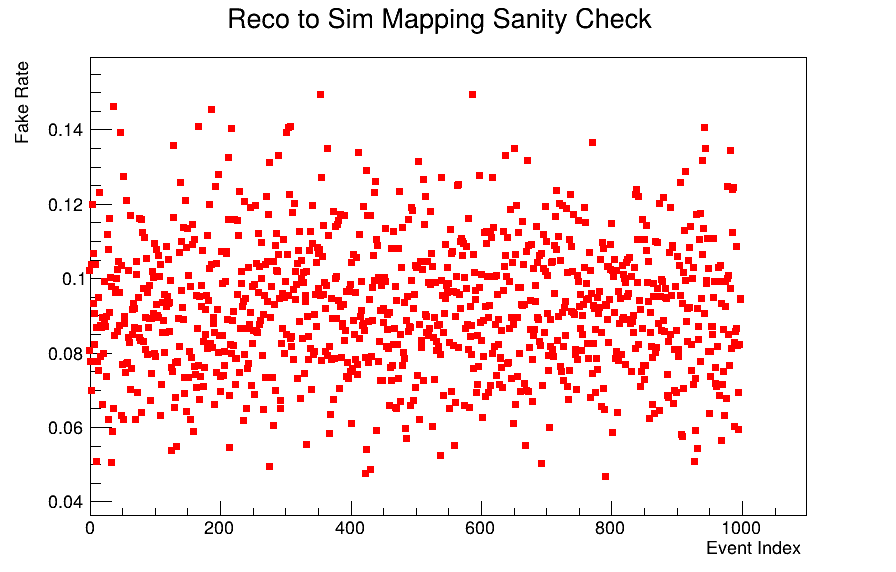

: 

In [ ]:
n = len(match_frac)

# --- Build graphs, skipping NaNs ---
g_match = ROOT.TGraph()
g_fake  = ROOT.TGraph()

km = 0
kf = 0
for i in range(n):
    mf = float(match_frac[i])
    fr = float(fake_rate[i])

    if not math.isnan(mf):
        g_match.SetPoint(km, i, mf)
        km += 1

    if not math.isnan(fr):
        g_fake.SetPoint(kf, i, fr)
        kf += 1

# -------- Plot 1: Matched fraction --------
c_match = ROOT.TCanvas("c_match", "Matched Fraction", 900, 600)
g_match.SetTitle("Reco to Sim Mapping Sanity Check;Event Index;Matched Fraction")
g_match.SetMarkerStyle(20)
g_match.SetMarkerColor(ROOT.kBlue)
g_match.SetMarkerSize(0.9)
g_match.Draw("AP")
c_match.Draw()

# -------- Plot 2: Fake rate --------
c_fake = ROOT.TCanvas("c_fake", "Fake Rate", 900, 600)
g_fake.SetTitle("Reco to Sim Mapping Sanity Check;Event Index;Fake Rate")
g_fake.SetMarkerStyle(21)
g_fake.SetMarkerColor(ROOT.kRed)
g_fake.SetMarkerSize(0.9)
g_fake.Draw("AP")

# Optional: force a visible y-range if everything is tiny
# g_fake.GetYaxis().SetRangeUser(0.0, 0.5)

c_fake.Draw()

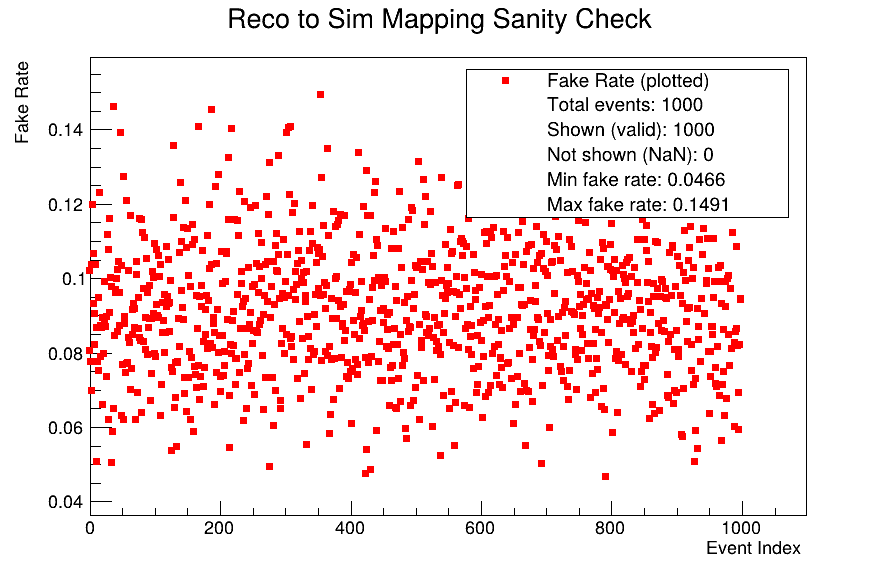

In [5]:
n = len(fake_rate)

g_fake = ROOT.TGraph()

kf = 0
n_valid = 0
n_nan   = 0

fake_vals = []

for i in range(n):
    fr = float(fake_rate[i])

    if not math.isnan(fr):
        g_fake.SetPoint(kf, i, fr)
        kf += 1
        n_valid += 1
        fake_vals.append(fr)
    else:
        n_nan += 1

# compute min/max safely
if len(fake_vals) > 0:
    fr_min = min(fake_vals)
    fr_max = max(fake_vals)
else:
    fr_min = float('nan')
    fr_max = float('nan')

# -------- Plot --------
c_fake = ROOT.TCanvas("c_fake", "Fake Rate", 900, 600)

g_fake.SetTitle("Reco to Sim Mapping Sanity Check;Event Index;Fake Rate")
g_fake.SetMarkerStyle(21)
g_fake.SetMarkerColor(ROOT.kRed)
g_fake.SetMarkerSize(0.9)
g_fake.Draw("AP")

# Optional zoom if needed
# g_fake.GetYaxis().SetRangeUser(0.0, 0.3)

# -------- Legend --------
leg = ROOT.TLegend(0.52, 0.62, 0.88, 0.88)

leg.AddEntry(g_fake, "Fake Rate (plotted)", "p")
leg.AddEntry(0, f"Total events: {n}", "")
leg.AddEntry(0, f"Shown (valid): {n_valid}", "")
leg.AddEntry(0, f"Not shown (NaN): {n_nan}", "")
leg.AddEntry(0, f"Min fake rate: {fr_min:.4f}", "")
leg.AddEntry(0, f"Max fake rate: {fr_max:.4f}", "")

leg.Draw()

c_fake.Draw()

In [ ]:
# pt, eta, phi analysis for matched pairs 

#=== Constants ===
ACCEPT_RATIO = 0.75
N_WORKERS = 10
PROGRESS_EVERY = 50
RUN = True

root_path = t.GetCurrentFile().GetName()
tree_name = t.GetName()

print("ROOT file:", root_path)
print("Tree name:", tree_name)

# pick chunk size based on n_workers and total entries
n_entries = int(t.GetEntries())
TARGET_CHUNKS = N_WORKERS * 4        
MIN_CHUNK = 25                      
CHUNK = max(MIN_CHUNK,
            math.ceil(n_entries / TARGET_CHUNKS))

print(f"Auto CHUNK size = {CHUNK}")

def find_ttree_in_file(f, target_name):
    obj = f.Get(target_name)
    if obj and obj.InheritsFrom("TTree"):
        return obj

    def _search_dir(d):
        keys = d.GetListOfKeys()
        if not keys:
            return None
        for key in keys:
            name = key.GetName()
            obj = d.Get(name)
            if not obj:
                continue
            if obj.InheritsFrom("TTree") and obj.GetName() == target_name:
                return obj
            if obj.InheritsFrom("TDirectory"):
                found = _search_dir(obj)
                if found:
                    return found
        return None

    return _search_dir(f)

def wrap_to_pi(dphi):
    # maps to [-pi, pi]
    return (dphi + np.pi) % (2.0 * np.pi) - np.pi

def _as_np(x):
    """
    Convert a ROOT std::vector-like to a numpy array (float64).
    Works for RVec too in most CMSSW builds.
    """
    # Many ROOT vector proxies support len() and indexing
    n = x.size()
    out = np.empty(n, dtype=np.float64)
    for i in range(n):
        out[i] = float(x[i])
    return out

def process_range(args):
    """
    Worker: open file/tree locally, process [start, end) events.
    Returns variable-length arrays of matched-pair residuals.
    """
    root_path, tree_name, start, end, accept_ratio = args

    f = ROOT.TFile.Open(root_path)
    if not f or f.IsZombie():
        raise RuntimeError(f"Could not open ROOT file: {root_path}")

    tt = find_ttree_in_file(f, tree_name)
    if not tt:
        f.Close()
        raise RuntimeError(f"Could not find TTree '{tree_name}' anywhere in {root_path}")

    # variable-length outputs (matched pairs only)
    out_event = []
    out_reco_i = []
    out_sim_j  = []
    out_dptpt  = []
    out_deta   = []
    out_dphi   = []

    processed = 0

    for evt in range(start, end):
        tt.GetEntry(evt)

        # --- Reco side ---
        trk_pt  = tt.trk_pt
        trk_eta = tt.trk_eta
        trk_phi = tt.trk_phi

        # --- Match info ---
        best_j      = tt.trk_bestSimTrkIdx
        share_frac  = tt.trk_bestSimTrkShareFrac

        # --- Sim side (EDIT THESE BRANCH NAMES IF YOUR TREE USES DIFFERENT ONES) ---
        # Common patterns are sim_pt/sim_eta/sim_phi, or sim_trk_pt, simTrk_pt, etc.
        sim_pt  = getattr(tt, "sim_pt", None)
        sim_eta = getattr(tt, "sim_eta", None)
        sim_phi = getattr(tt, "sim_phi", None)
        if sim_pt is None or sim_eta is None or sim_phi is None:
            f.Close()
            raise RuntimeError(
                "Could not find sim branches (sim_pt/sim_eta/sim_phi). "
                "Edit the getattr(...) names in process_range to match your tree."
            )

        N_reco = trk_pt.size()
        if N_reco == 0:
            processed += 1
            continue

        # loop reco tracks, keep matched pairs only
        for i in range(N_reco):
            j = int(best_j[i])
            if j < 0:
                continue
            if float(share_frac[i]) < accept_ratio:
                continue

            spt = float(sim_pt[j])
            if spt == 0.0:
                # avoid inf; you can also choose np.nan here
                continue

            rpt  = float(trk_pt[i])
            reta = float(trk_eta[i])
            rphi = float(trk_phi[i])

            seta = float(sim_eta[j])
            sphi = float(sim_phi[j])

            out_event.append(evt)
            out_reco_i.append(i)
            out_sim_j.append(j)

            out_dptpt.append((rpt - spt) / spt)
            out_deta.append(reta - seta)
            out_dphi.append(wrap_to_pi(rphi - sphi))

        processed += 1

    f.Close()

    # convert to numpy once at end
    return (
        np.asarray(out_event, dtype=np.int64),
        np.asarray(out_reco_i, dtype=np.int32),
        np.asarray(out_sim_j,  dtype=np.int32),
        np.asarray(out_dptpt,  dtype=np.float64),
        np.asarray(out_deta,   dtype=np.float64),
        np.asarray(out_dphi,   dtype=np.float64),
        processed
    )

# chunk ranges
n_entries = int(t.GetEntries())
ranges = [
    (root_path, tree_name, s, min(s + CHUNK, n_entries), ACCEPT_RATIO)
    for s in range(0, n_entries, CHUNK)
]

print(f"Total entries: {n_entries}")
print(f"Chunks: {len(ranges)} (chunk size {CHUNK}), workers: {N_WORKERS}")

all_event, all_reco_i, all_sim_j = [], [], []
all_dptpt, all_deta, all_dphi   = [], [], []

done = 0
last_print = 0

if RUN:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        futures = [ex.submit(process_range, r) for r in ranges]

        for fut in as_completed(futures):
            ev, ri, sj, dptpt, deta, dphi, processed = fut.result()

            all_event.append(ev)
            all_reco_i.append(ri)
            all_sim_j.append(sj)
            all_dptpt.append(dptpt)
            all_deta.append(deta)
            all_dphi.append(dphi)

            done += processed
            if done - last_print >= PROGRESS_EVERY or done == n_entries:
                pct = 100.0 * done / n_entries if n_entries > 0 else 100.0
                print(f"{done}/{n_entries} events processed ({pct:.1f}%)")
                last_print = done

    # concatenate all matched pairs across chunks
    event_id = np.concatenate(all_event) if all_event else np.array([], dtype=np.int64)
    reco_i   = np.concatenate(all_reco_i) if all_reco_i else np.array([], dtype=np.int32)
    sim_j    = np.concatenate(all_sim_j)  if all_sim_j else np.array([], dtype=np.int32)
    dptpt    = np.concatenate(all_dptpt)  if all_dptpt else np.array([], dtype=np.float64)
    deta     = np.concatenate(all_deta)   if all_deta else np.array([], dtype=np.float64)
    dphi     = np.concatenate(all_dphi)   if all_dphi else np.array([], dtype=np.float64)

    # stable ordering (by event, then reco index)
    if event_id.size > 0:
        order = np.lexsort((reco_i, event_id))
        event_id = event_id[order]
        reco_i   = reco_i[order]
        sim_j    = sim_j[order]
        dptpt    = dptpt[order]
        deta     = deta[order]
        dphi     = dphi[order]

    np.savez(
        "reco_vs_truth_agreement_cache_parallel.npz",
        event_id=event_id,
        reco_i=reco_i,
        sim_j=sim_j,
        dpt_over_pt=dptpt,
        d_eta=deta,
        d_phi=dphi,
        accept_ratio=np.float64(ACCEPT_RATIO),
    )
    print("Saved locally to reco_vs_truth_agreement_cache_parallel.npz")
    print(f"Matched pairs saved: {event_id.size}")

else:
    print("skipping run")

In [ ]:
run = NPZData("reco_vs_truth_agreement_cache_parallel.npz")

print(run.keys())

In [ ]:
run = NPZData("reco_vs_truth_agreement_cache_parallel.npz")

event_id = run.event_id
dptpt    = run.dpt_over_pt
deta     = run.d_eta
dphi     = run.d_phi

# --- finite filter (keeps arrays aligned) ---
mask = np.isfinite(dptpt) & np.isfinite(deta) & np.isfinite(dphi)
event_id = event_id[mask]
dptpt    = dptpt[mask]
deta     = deta[mask]
dphi     = dphi[mask]

print("Valid matched pairs:", len(event_id))

# =========================
# 1D residual histograms
# =========================
h_dptpt = ROOT.TH1F("h_dptpt",
                    "(p_{T}^{reco}-p_{T}^{sim})/p_{T}^{sim};Residual;Matched pairs",
                    120, -1.0, 1.0)
for v in dptpt: h_dptpt.Fill(float(v))
c_dptpt = ROOT.TCanvas("c_dptpt", "dpt/pt", 900, 600)
h_dptpt.SetLineWidth(2)
h_dptpt.Draw("HIST")
c_dptpt.Draw()

h_deta = ROOT.TH1F("h_deta",
                   "#eta^{reco}-#eta^{sim};Residual;Matched pairs",
                   120, -0.5, 0.5)
for v in deta: h_deta.Fill(float(v))
c_deta = ROOT.TCanvas("c_deta", "deta", 900, 600)
h_deta.SetLineWidth(2)
h_deta.Draw("HIST")
c_deta.Draw()

h_dphi = ROOT.TH1F("h_dphi",
                   "#phi^{reco}-#phi^{sim} (wrapped);Residual;Matched pairs",
                   120, -math.pi, math.pi)
for v in dphi: h_dphi.Fill(float(v))
c_dphi = ROOT.TCanvas("c_dphi", "dphi", 900, 600)
h_dphi.SetLineWidth(2)
h_dphi.Draw("HIST")
c_dphi.Draw()

# =========================
# 2D sanity plots
# =========================
h_etaphi = ROOT.TH2F("h_etaphi",
                     "d#eta vs d#phi;d#eta;d#phi",
                     100, -0.5, 0.5,
                     100, -math.pi, math.pi)
for x, y in zip(deta, dphi):
    h_etaphi.Fill(float(x), float(y))
c_etaphi = ROOT.TCanvas("c_etaphi", "deta vs dphi", 900, 600)
h_etaphi.Draw("COLZ")
c_etaphi.Draw()

h_pt_eta = ROOT.TH2F("h_pt_eta",
                     "d#eta vs dpt/pt;d#eta;dpt/pt",
                     100, -0.5, 0.5,
                     100, -1.0, 1.0)
for x, y in zip(deta, dptpt):
    h_pt_eta.Fill(float(x), float(y))
c_pt_eta = ROOT.TCanvas("c_pt_eta", "deta vs dpt/pt", 900, 600)
h_pt_eta.Draw("COLZ")
c_pt_eta.Draw()

h_pt_phi = ROOT.TH2F("h_pt_phi",
                     "d#phi vs dpt/pt;d#phi;dpt/pt",
                     100, -math.pi, math.pi,
                     100, -1.0, 1.0)
for x, y in zip(dphi, dptpt):
    h_pt_phi.Fill(float(x), float(y))
c_pt_phi = ROOT.TCanvas("c_pt_phi", "dphi vs dpt/pt", 900, 600)
h_pt_phi.Draw("COLZ")
c_pt_phi.Draw()

# =========================
# Event-level graphs (like your old sanity plots)
# =========================
if len(event_id) > 0:
    ev_unique, counts = np.unique(event_id, return_counts=True)
    x = np.arange(len(ev_unique), dtype=np.float64)  # compressed event index

    # --- Graph: matched pairs per event ---
    g_pairs = ROOT.TGraph()
    for i in range(len(ev_unique)):
        g_pairs.SetPoint(i, float(i), float(counts[i]))

    c_pairs = ROOT.TCanvas("c_pairs", "Pairs per Event", 900, 600)
    g_pairs.SetTitle("Reco#rightarrowSim Mapping Sanity Check;Event (compressed index);# matched pairs")
    g_pairs.SetMarkerStyle(20)
    g_pairs.SetMarkerSize(0.8)
    g_pairs.Draw("AP")
    c_pairs.Draw()

    # --- Mean |residual| per event for each residual ---
    order = np.argsort(event_id)
    evs   = event_id[order]
    dpt_s = dptpt[order]
    de_s  = deta[order]
    dp_s  = dphi[order]

    mean_abs_dpt = np.zeros(len(ev_unique), dtype=np.float64)
    mean_abs_de  = np.zeros(len(ev_unique), dtype=np.float64)
    mean_abs_dp  = np.zeros(len(ev_unique), dtype=np.float64)

    start = 0
    n = len(evs)
    for k, ev in enumerate(ev_unique):
        end = start
        while end < n and evs[end] == ev:
            end += 1
        mean_abs_dpt[k] = float(np.mean(np.abs(dpt_s[start:end]))) if end > start else np.nan
        mean_abs_de[k]  = float(np.mean(np.abs(de_s[start:end])))  if end > start else np.nan
        mean_abs_dp[k]  = float(np.mean(np.abs(dp_s[start:end])))  if end > start else np.nan
        start = end

    def make_meanabs_graph(y, name, title):
        g = ROOT.TGraph()
        kk = 0
        for i in range(len(y)):
            val = float(y[i])
            if not math.isnan(val) and math.isfinite(val):
                g.SetPoint(kk, float(i), val)
                kk += 1
        c = ROOT.TCanvas(name, name, 900, 600)
        g.SetTitle(title)
        g.SetMarkerStyle(21)
        g.SetMarkerSize(0.8)
        g.Draw("AP")
        c.Draw()
        return c, g

    c_m1, g_m1 = make_meanabs_graph(mean_abs_dpt, "c_meanabs_dptpt",
                                    "Mean |dpt/pt| per event;Event (compressed index);Mean |dpt/pt|")
    c_m2, g_m2 = make_meanabs_graph(mean_abs_de,  "c_meanabs_deta",
                                    "Mean |d#eta| per event;Event (compressed index);Mean |d#eta|")
    c_m3, g_m3 = make_meanabs_graph(mean_abs_dp,  "c_meanabs_dphi",
                                    "Mean |d#phi| per event;Event (compressed index);Mean |d#phi|")